In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


In [10]:
#load dataset

df = pd.read_csv("bank.csv", sep=";")
print(df)


      age            job  marital  education default  balance housing loan  \
0      30     unemployed  married    primary      no     1787      no   no   
1      33       services  married  secondary      no     4789     yes  yes   
2      35     management   single   tertiary      no     1350     yes   no   
3      30     management  married   tertiary      no     1476     yes  yes   
4      59    blue-collar  married  secondary      no        0     yes   no   
...   ...            ...      ...        ...     ...      ...     ...  ...   
4516   33       services  married  secondary      no     -333     yes   no   
4517   57  self-employed  married   tertiary     yes    -3313     yes  yes   
4518   57     technician  married  secondary      no      295      no   no   
4519   28    blue-collar  married  secondary      no     1137      no   no   
4520   44   entrepreneur   single   tertiary      no     1136     yes  yes   

       contact  day month  duration  campaign  pdays  previous 

In [11]:
# Remove target variable
X = df.drop("y", axis=1)
# One-hot encoding
X = pd.get_dummies(X, drop_first=True)


In [12]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [14]:
# DBSCAN
db = DBSCAN(eps=0.8, min_samples=10)
db_labels = db.fit_predict(X_scaled)


In [15]:
# Silhouette score for DBSCAN
valid_mask = db_labels != -1
if len(np.unique(db_labels[valid_mask])) > 1:
    sil_db = silhouette_score(X_scaled[valid_mask], db_labels[valid_mask])
else:
    sil_db = "Not defined"


In [16]:
# EM / GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, gmm_labels)

print("DBSCAN Silhouette Score:", sil_db)
print("GMM Silhouette Score:", sil_gmm)


DBSCAN Silhouette Score: Not defined
GMM Silhouette Score: 0.03340514885986419


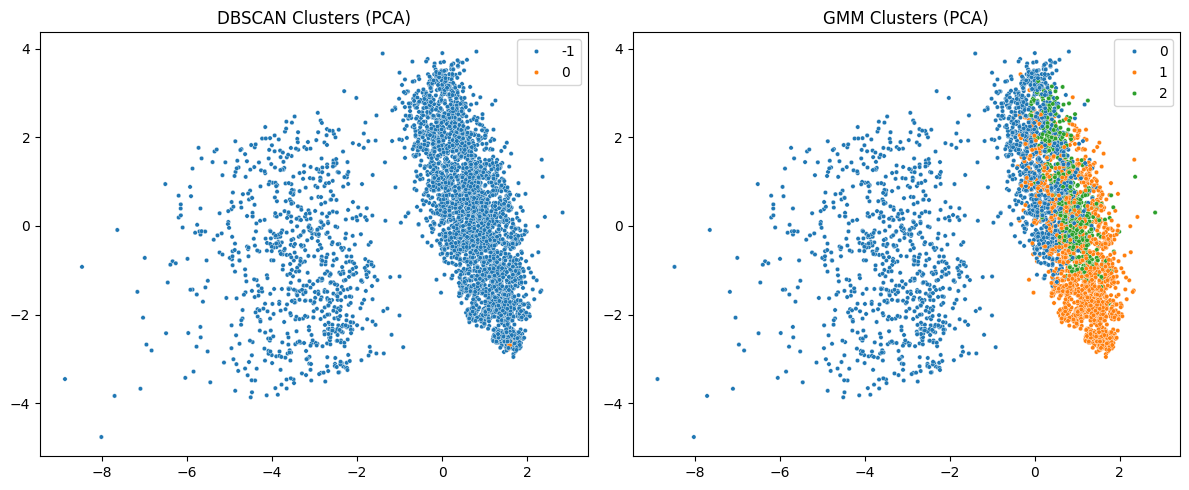

In [17]:
# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("DBSCAN Clusters (PCA)")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=db_labels, palette="tab10", s=10)

plt.subplot(1, 2, 2)
plt.title("GMM Clusters (PCA)")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette="tab10", s=10)

plt.tight_layout()
plt.show()
